# Ensemble Techniques — Bagging vs Boosting (Hands-on Demo)

This notebook is a **hands-on companion** to the theory notes on Ensemble Techniques.

We'll use a synthetic classification dataset (generated with `make_classification`) so everything
here runs immediately without needing any external file.

**What you'll see in this notebook:**
1. A single Decision Tree (baseline)
2. **Bagging** — many trees trained in parallel on random samples, combined by majority vote
3. **Boosting (AdaBoost)** — many weak learners trained sequentially, each fixing the previous one's mistakes
4. **Random Forest** — the most popular Bagging algorithm (Decision Trees + row/feature sampling)
5. A simple bar chart comparing all of their accuracies



## 1. Imports & Synthetic Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create a synthetic binary classification dataset
X, y = make_classification(
    n_samples=2000, n_features=15, n_informative=8, n_redundant=2,
    n_classes=2, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1500, 15)  Test shape: (500, 15)


## 2. Baseline — A Single Decision Tree

A single Decision Tree tends to **overfit** — it can memorize training data patterns that don't
generalize well to new/unseen data.

In [2]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt.predict(X_test))
print(f"Decision Tree -> Train Accuracy: {dt_train_acc:.3f} | Test Accuracy: {dt_test_acc:.3f}")


Decision Tree -> Train Accuracy: 1.000 | Test Accuracy: 0.794


## 3. Bagging — Many Trees Trained in Parallel

`BaggingClassifier` trains many copies of a base estimator (here, Decision Trees) on **random
samples of the data** (bootstrapped), all **in parallel**, then combines predictions via majority vote.

In [3]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,   # number of base learners (trees)
    random_state=42
)
bagging_model.fit(X_train, y_train)

bag_train_acc = accuracy_score(y_train, bagging_model.predict(X_train))
bag_test_acc = accuracy_score(y_test, bagging_model.predict(X_test))
print(f"Bagging -> Train Accuracy: {bag_train_acc:.3f} | Test Accuracy: {bag_test_acc:.3f}")


Bagging -> Train Accuracy: 1.000 | Test Accuracy: 0.858


## 4. Random Forest — Bagging + Decision Trees + Feature Sampling

Random Forest is the most popular Bagging algorithm. It's similar to plain Bagging, but it *also*
randomly samples **features** (not just rows) for every tree — which usually improves performance further.

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Random Forest -> Train Accuracy: {rf_train_acc:.3f} | Test Accuracy: {rf_test_acc:.3f}")


Random Forest -> Train Accuracy: 1.000 | Test Accuracy: 0.862


## 5. Boosting (AdaBoost) — Weak Learners Trained Sequentially

`AdaBoostClassifier` trains weak learners **one after another**, giving more weight to the
records that previous learners got wrong, gradually building a "strong learner".

In [5]:
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

ada_train_acc = accuracy_score(y_train, ada_model.predict(X_train))
ada_test_acc = accuracy_score(y_test, ada_model.predict(X_test))
print(f"AdaBoost -> Train Accuracy: {ada_train_acc:.3f} | Test Accuracy: {ada_test_acc:.3f}")


AdaBoost -> Train Accuracy: 0.789 | Test Accuracy: 0.762


## 6. Comparing All Models

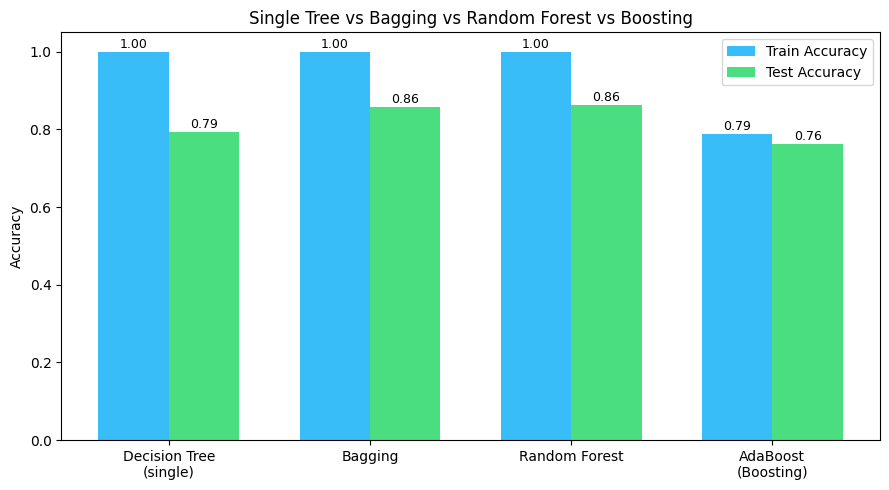

In [6]:
results = {
    "Decision Tree\n(single)": (dt_train_acc, dt_test_acc),
    "Bagging": (bag_train_acc, bag_test_acc),
    "Random Forest": (rf_train_acc, rf_test_acc),
    "AdaBoost\n(Boosting)": (ada_train_acc, ada_test_acc),
}

names = list(results.keys())
train_vals = [results[n][0] for n in names]
test_vals = [results[n][1] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, train_vals, width, label='Train Accuracy', color='#38bdf8')
ax.bar(x + width/2, test_vals, width, label='Test Accuracy', color='#4ade80')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Accuracy')
ax.set_title('Single Tree vs Bagging vs Random Forest vs Boosting')
ax.legend()
ax.set_ylim(0, 1.05)
for i, v in enumerate(train_vals):
    ax.text(i - width/2, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
for i, v in enumerate(test_vals):
    ax.text(i + width/2, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 7. Key Takeaways

- ✅ A **single Decision Tree** usually has a noticeable gap between train and test accuracy (overfitting).
- ✅ **Bagging** and **Random Forest** reduce this gap by combining many trees trained on different
  random samples — Random Forest additionally samples features, often edging out plain Bagging.
- ✅ **Boosting (AdaBoost)** builds strong learners sequentially — performance depends heavily on the
  number of estimators and learning rate (try changing `n_estimators` above and re-running!).
- ✅ **Try it yourself:** Change `n_estimators`, `max_depth`, or the dataset parameters in
  `make_classification` and re-run the cells to see how the results shift.

### Next notebook
➡️ **`02_Random_Forest_Theory_Demo.ipynb`** — a deeper look at *why* Random Forest reduces overfitting
   (bias-variance tradeoff) and how row/feature sampling works under the hood.
